# Dnipro: calendar shift detection (presentation version)

Presentation-styled version of `Dnipro_rolling_lag_ta.png` (from `dataprep_calendarshift_detection.py`): best-matching lag between Dnipro station temperature and 20CRv3 reanalysis, computed in rolling windows over time. Reads the already-computed rolling-lag series from `image/Ukraine_calendar_shifts/Dnipro_bestlag_ta.txt` rather than recomputing it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 20,
})

julian_color = "#1f77b4"    # blue: Julian-calendar dates (negative lag)
gregorian_color = "#e4003c"  # unibern red: Gregorian-calendar dates (positive lag)
cutoff = pd.Timestamp("1838-12-15")  # documented transition date, see image/Ukraine_calendar_shifts/readme.md


In [2]:
bestlag = pd.read_csv(
    "image/Ukraine_calendar_shifts/Dnipro_bestlag_ta.txt",
    sep=r"\s+",
    header=None,
    names=["Date", "Best_Lag", "Best_Corr"],
)
bestlag["Date"] = pd.to_datetime(bestlag["Date"])
bestlag.head()


,Date,Best_Lag,Best_Corr
0,1833-04-01,-13,0.933
1,1833-05-31,-13,0.829
2,1833-07-30,-20,0.747
3,1833-09-28,-13,0.929
4,1833-11-27,-12,0.916


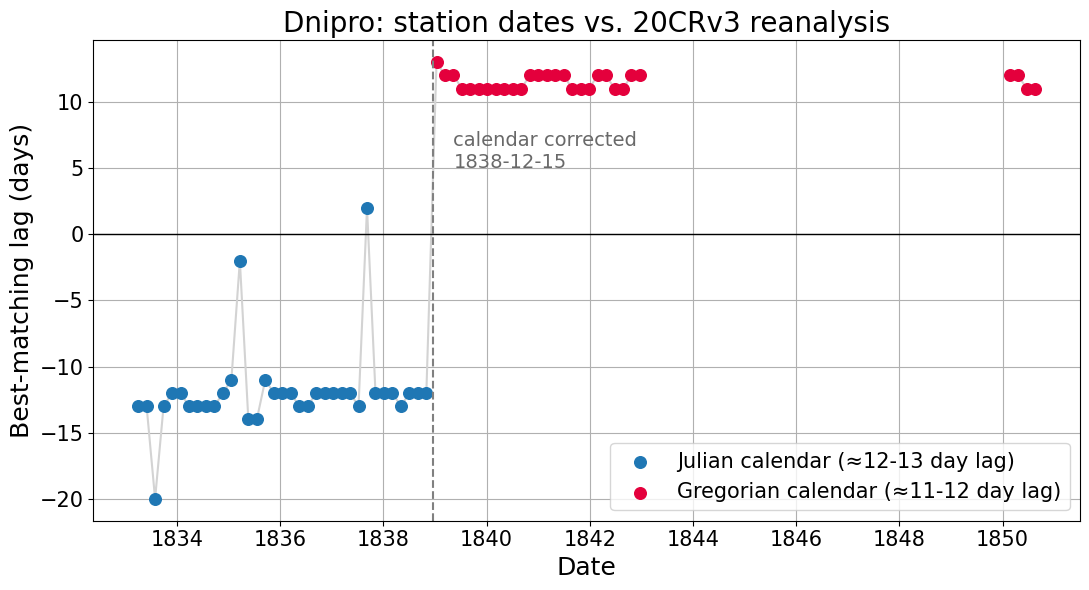

In [3]:
fig, ax = plt.subplots()

# break the connecting line across large data gaps (e.g. 1843 -> 1850)
gap = bestlag["Date"].diff().dt.days
line_lag = bestlag["Best_Lag"].mask(gap > 400)
ax.plot(bestlag["Date"], line_lag, color="lightgray", lw=1.5, zorder=1)

before = bestlag[bestlag["Date"] <= cutoff]
after = bestlag[bestlag["Date"] > cutoff]

ax.scatter(before["Date"], before["Best_Lag"], color=julian_color, s=70,
           label="Julian calendar (≈12-13 day lag)", zorder=2)
ax.scatter(after["Date"], after["Best_Lag"], color=gregorian_color, s=70,
           label="Gregorian calendar (≈11-12 day lag)", zorder=2)

ax.axhline(0, color="black", lw=1)
ax.axvline(cutoff, color="gray", linestyle="--", lw=1.5)
ax.annotate(f"calendar corrected\n{cutoff.date()}", xy=(cutoff, 5), xytext=(15, 0),
            textcoords="offset points", fontsize=14, color="dimgray")

ax.set_xlabel("Date")
ax.set_ylabel("Best-matching lag (days)")
ax.set_title("Dnipro: station dates vs. 20CRv3 reanalysis")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("image/dnipro_rolling_lag_ta_presentation.png", dpi=300)
fig.savefig("image/dnipro_rolling_lag_ta_presentation.pdf")
